In [2]:
pip install -qU langgraph


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='97978865-32e2-4871-85d7-400d8aea38b3'),
  AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='6bd4dcec-5f95-4a23-bce6-aee53f12d12a', tool_calls=[], invalid_tool_calls=[])]}

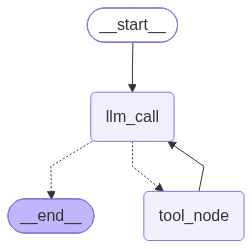

TypeError: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [25]:
# Step 1: Define tools and model

from langchain.tools import tool
from langchain.chat_models import init_chat_model


model = init_chat_model(
    "claude-sonnet-4-6",
    temperature=0
)


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get('llm_calls', 0) + 1
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [19]:
#chatbot

from typing import List, Dict
from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage
from langchain_ollama import ChatOllama
from dotenv import load_dotenv

load_dotenv()


class State(Dict):
    messages:List[Dict[str,str]]

graph_builder=StateGraph(State)

llm= ChatOllama(
    model="phi3:latest",
    temperature=0.5,
    task="text generation"
)


In [20]:
llm2=ChatGroq(
    model="lamma-3.3-70b-versatile",
    temperature=0.7
)

In [21]:
#node
def chatbot(State:State):
    message=[]
    for msg in state["messages"]:
        if msg["role"]=="user":
            message.append(HumanMessge(content=msg["content"]))
        elif msg["role"]=="assistent":
            messafe.append(HumanMessage(content=msg["content"]))
    response=llm.invoke(messages)
    return{"message" : [{"role" : "assistent", "content": response.content }]}
    

In [22]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph=graph_builder.compile()

In [23]:
def stream_graph_updates(uer_input:str):
    state={"message":[{"role":"user", "content":user_input}]}
    for event in graph.stream(state):
        for value in event.values():
            for msg in value:
                for msg in value["messages"]:
                    if msg["role"]=="assistent":
                           print("Assistant:", msg["content"])

In [24]:
print("Chatbot is ready! Type 'quit' to exit.\n")

while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye! ")
            break
        stream_graph_updates(user_input)
    except Exception as e:
        print(f" Error: {e}")
        break

Chatbot is ready! Type 'quit' to exit.



User:  hi


 Error: name 'state' is not defined
